<a href="https://colab.research.google.com/github/adhibgs/data-science-2025/blob/main/Pertemuan13_Adhi_Bagus_May_Maulana_250401020116.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pertemuan ke-13

*   Nama : Adhi Bagus May Maulana
*   NIM : 250401020116
*   Kelas : IF405

Langkah 1: Generate & Eksplorasi Dataset Non-Linear


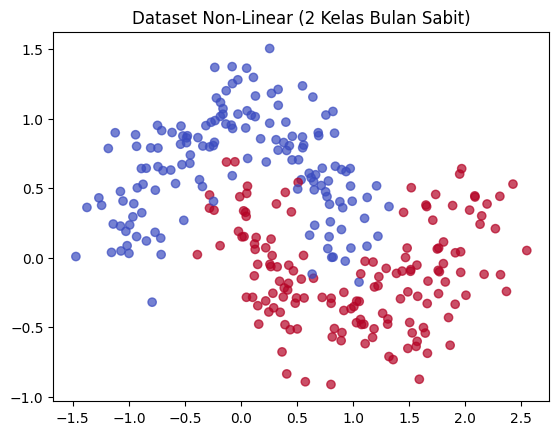

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.show()

Langkah 2: Bangun & Latih Neural Network Sederhana


In [2]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
X_tr, X_te, y_tr, y_te = train_test_split(
X, y, test_size=0.2, random_state=42)
model = Sequential([
Dense(16, activation='relu', input_shape=(2,)),
Dense(8, activation='relu'),
Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy',
metrics=['accuracy'])
model.summary()
history = model.fit(X_tr, y_tr, epochs=30,
validation_split=0.2, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Langkah 3: Evaluasi & Visualisasi Kurva Belajar


Akurasi pada data uji: 0.883


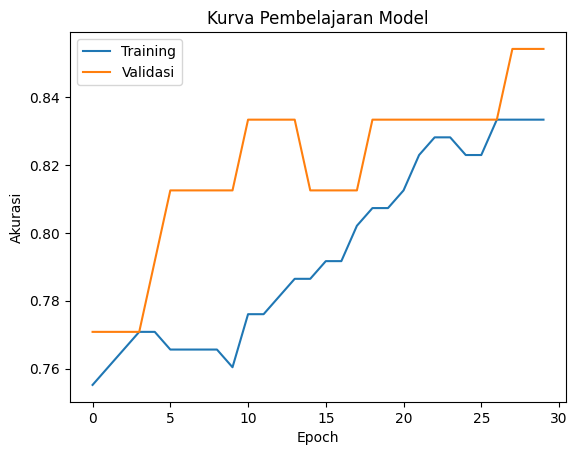

In [3]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch'); plt.ylabel('Akurasi')
plt.legend(); plt.title('Kurva Pembelajaran Model')
plt.show()

Langkah 4: Siapkan Dataset Ulasan Produk


In [5]:
ulasan = [
'Barangnya bagus banget, pengiriman cepat',
'Kualitas jelek, tidak sesuai deskripsi',
'Sangat puas, akan beli lagi',
'Kecewa, barang rusak saat sampai',
'Recommended, harga sesuai kualitas',
'Buruk sekali, tidak sesuai ekspektasi',
# ... tambahkan hingga 40 ulasan
]
label = [1, 0, 1, 0, 1, 0] # 1 = positif, 0 = negatif

Langkah 5: Ubah Teks Menjadi TF-IDF


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)
print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 25
['akan' 'bagus' 'banget' 'barang' 'barangnya' 'beli' 'buruk' 'cepat'
 'deskripsi' 'ekspektasi']


Langkah 6: Latih Model Klasifikasi Sentimen & Evaluasi


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
X_text, label, test_size=0.2, random_state=42)
model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)
akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print('Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.000
Positif
